<a href="https://colab.research.google.com/github/DataCommanderUsher/DSA-Case-Study-1-Amazon-Product-Review-Analysis/blob/main/Team_Force_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TEAM FORCE - BUSINESS ANALYSIS 3.2 PROJECT: AI DEMAND FORECASTING MODEL

In [18]:
#import all the necessary libraries for our project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report

In [3]:
logistics_df = pd.read_csv("https://raw.githubusercontent.com/VUT-BA-3-2-Project-2025/Team-force/main/logistics_dataset.csv")
logistics_df.head()

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670


In [11]:
#Starting Exploratory Data Analysis EDA
logistics_df.describe()

,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,picking_time_seconds,handling_cost_per_unit,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,forecasted_demand_next_7d,KPI_score
count,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000
mean,263.491573,54.759363,8.507803,5.578340,25.435868,5.260078,0.542325,95.606429,2.777116,105.887575,1.045993,4.602372,0.849738,521.714732,8.123677,0.600581,154.286245,0.601737
std,138.568360,26.053354,3.473229,2.292486,14.038861,2.725639,0.259200,49.218084,1.305213,54.428161,0.550480,2.883708,0.086703,276.768531,4.069191,0.230511,82.945255,0.108286
min,20.000000,10.000000,3.000000,2.000000,1.010000,0.500000,0.100000,10.000000,0.500000,10.220000,0.100000,0.000000,0.700000,50.000000,1.000000,0.200000,10.090000,0.259000
25%,144.000000,32.000000,5.000000,4.000000,13.535000,2.917500,0.310000,53.000000,1.660000,59.760000,0.580000,2.000000,0.780000,283.000000,4.590000,0.400000,83.190000,0.527000
50%,264.000000,55.000000,9.000000,6.000000,25.405000,5.235000,0.540000,96.000000,2.810000,106.005000,1.050000,5.000000,0.850000,513.500000,8.150000,0.600000,152.870000,0.601000
75%,386.000000,78.000000,12.000000,8.000000,37.412500,7.542500,0.760000,138.000000,3.910000,152.410000,1.522500,7.000000,0.920000,764.250000,11.692500,0.800000,225.440000,0.677250
max,499.000000,99.000000,14.000000,9.000000,49.980000,10.000000,1.000000,179.000000,5.000000,200.000000,2.000000,9.000000,1.000000,999.000000,15.000000,1.000000,299.940000,0.936000


In [12]:
logistics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_id                    3204 non-null   object 
 1   category                   3204 non-null   object 
 2   stock_level                3204 non-null   int64  
 3   reorder_point              3204 non-null   int64  
 4   reorder_frequency_days     3204 non-null   int64  
 5   lead_time_days             3204 non-null   int64  
 6   daily_demand               3204 non-null   float64
 7   demand_std_dev             3204 non-null   float64
 8   item_popularity_score      3204 non-null   float64
 9   storage_location_id        3204 non-null   object 
 10  zone                       3204 non-null   object 
 11  picking_time_seconds       3204 non-null   int64  
 12  handling_cost_per_unit     3204 non-null   float64
 13  unit_price                 3204 non-null   float

In [9]:
# Convert date column to datetime objects
logistics_df['last_restock_date'] = pd.to_datetime(logistics_df['last_restock_date'])

In [13]:
logistics_df.isnull().sum()

,0
item_id,0
category,0
stock_level,0
reorder_point,0
reorder_frequency_days,0
lead_time_days,0
daily_demand,0
demand_std_dev,0
item_popularity_score,0
storage_location_id,0


In [7]:
# Count unique values for each column
for col in logistics_df.columns:
    print(f"number of unique values in '{col}' is {logistics_df[col].nunique()}")

number of unique values in 'item_id' is 3204
number of unique values in 'category' is 5
number of unique values in 'stock_level' is 479
number of unique values in 'reorder_point' is 90
number of unique values in 'reorder_frequency_days' is 12
number of unique values in 'lead_time_days' is 8
number of unique values in 'daily_demand' is 2375
number of unique values in 'demand_std_dev' is 910
number of unique values in 'item_popularity_score' is 91
number of unique values in 'storage_location_id' is 100
number of unique values in 'zone' is 4
number of unique values in 'picking_time_seconds' is 170
number of unique values in 'handling_cost_per_unit' is 451
number of unique values in 'unit_price' is 2962
number of unique values in 'holding_cost_per_unit_day' is 191
number of unique values in 'stockout_count_last_month' is 10
number of unique values in 'order_fulfillment_rate' is 31
number of unique values in 'total_orders_last_month' is 922
number of unique values in 'turnover_ratio' is 125

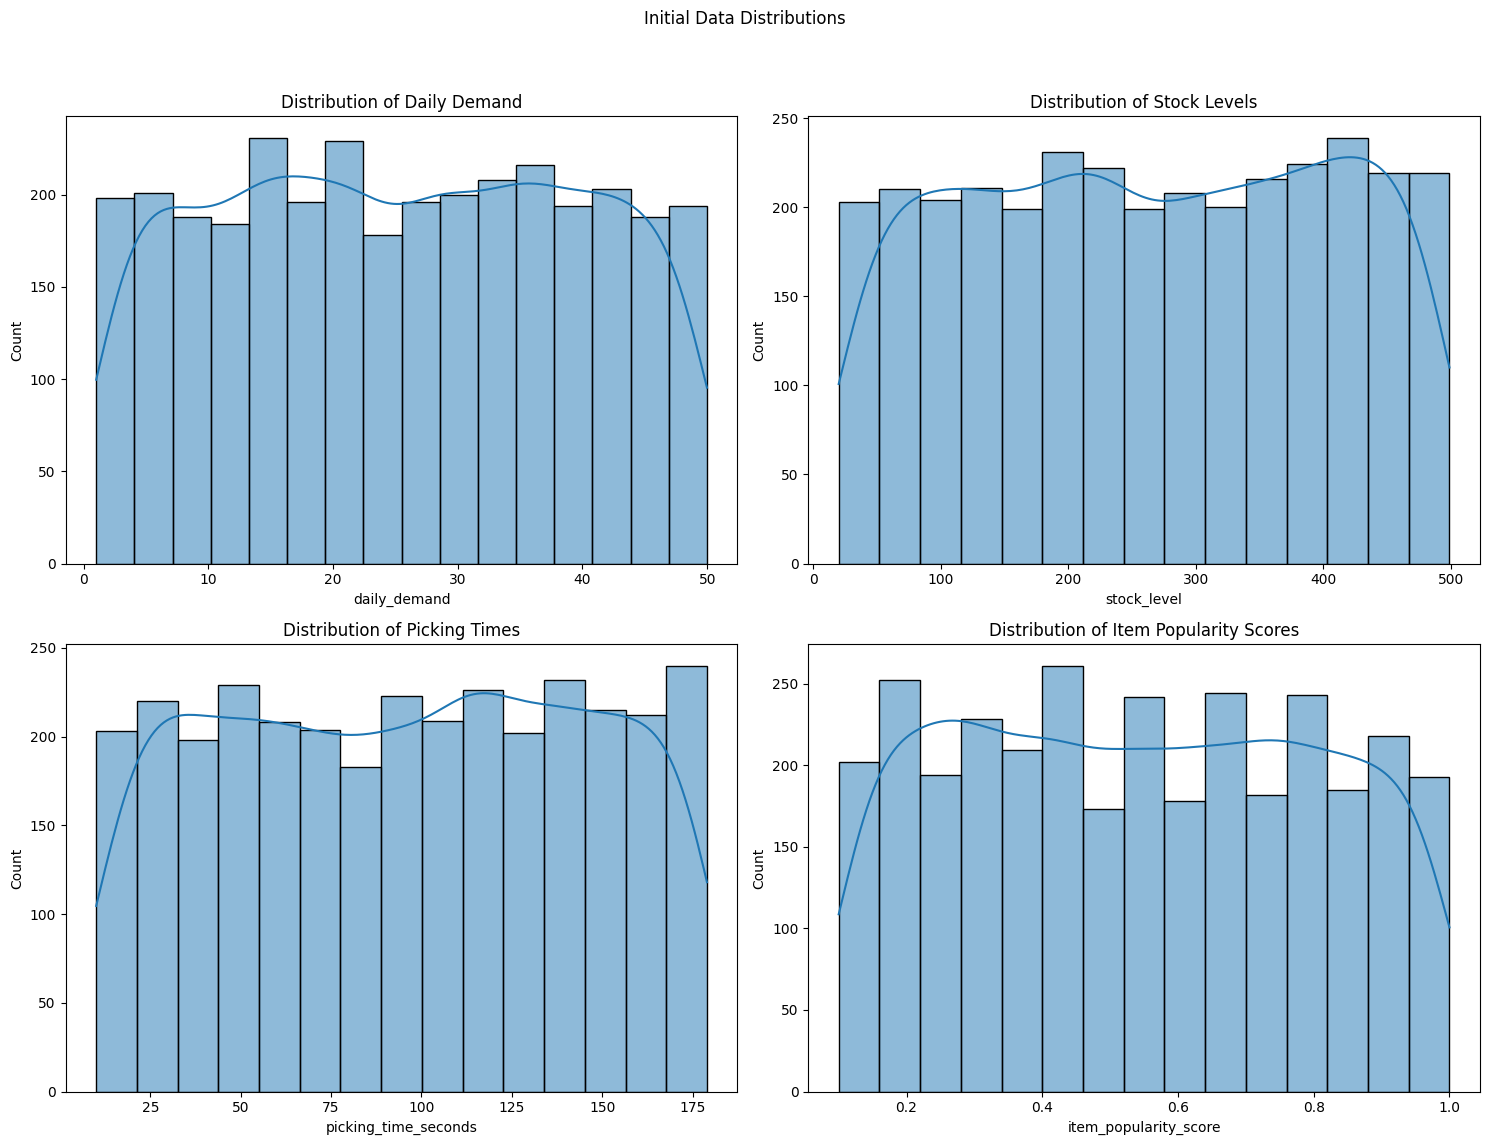

In [8]:
#Visualize our dataset to find patterns
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1)
sns.histplot(logistics_df['daily_demand'], kde=True)
plt.title('Distribution of Daily Demand')

plt.subplot(2, 2, 2)
sns.histplot(logistics_df['stock_level'], kde=True)
plt.title('Distribution of Stock Levels')
plt.subplot(2, 2, 3)

sns.histplot(logistics_df['picking_time_seconds'], kde=True)
plt.title('Distribution of Picking Times')
plt.subplot(2, 2, 4)

sns.histplot(logistics_df['item_popularity_score'], kde=True)
plt.title('Distribution of Item Popularity Scores')
plt.suptitle('Initial Data Distributions')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

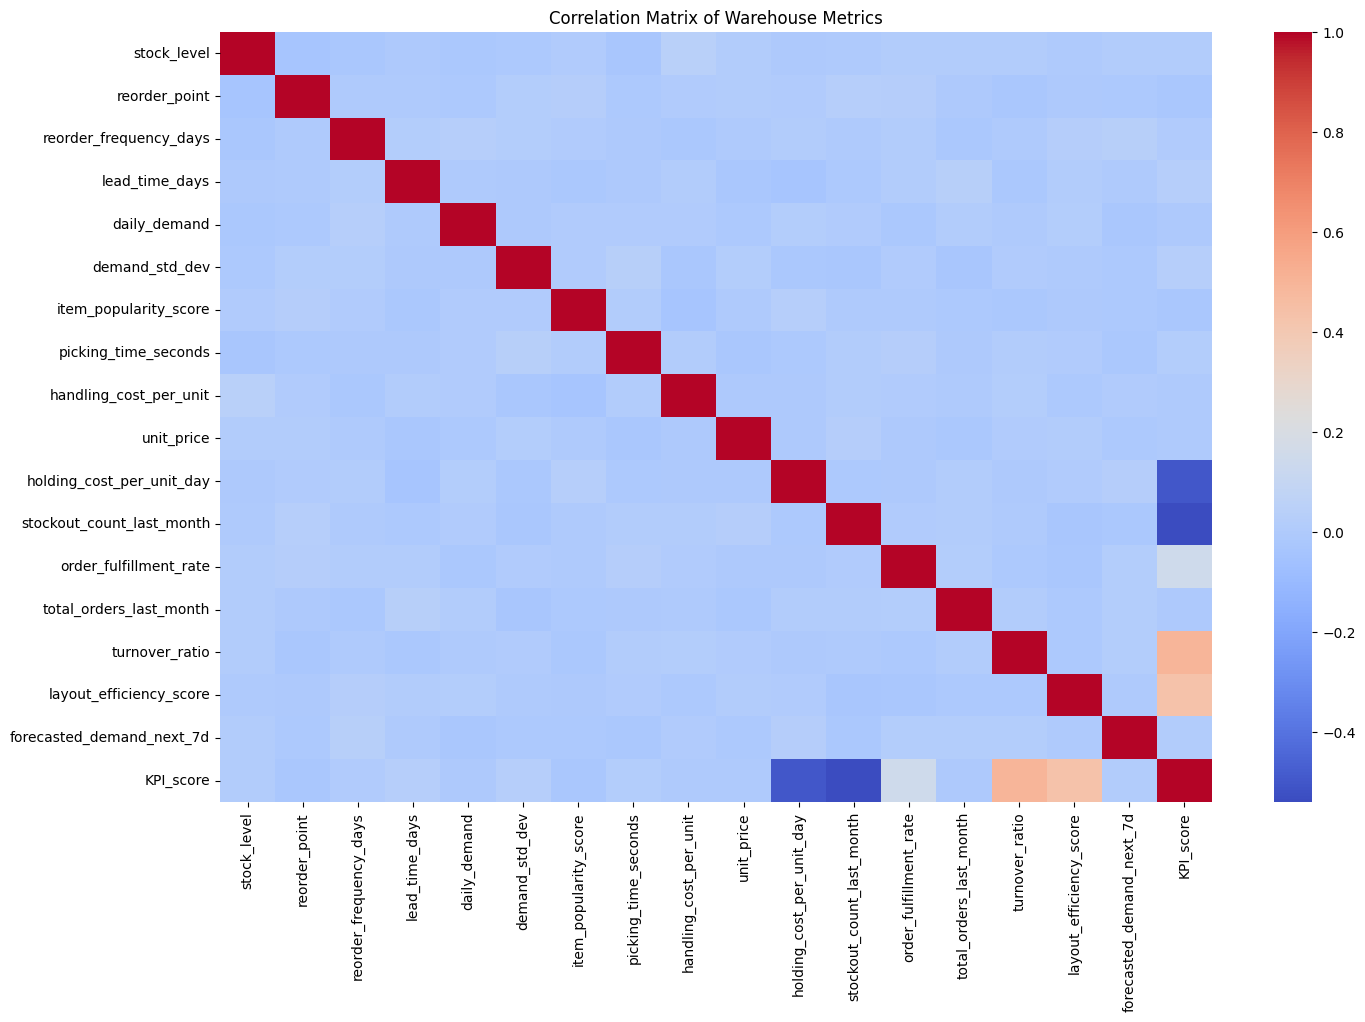

In [15]:
# # Visualization 2: Correlation Heatmap to see relationships between variables
plt.figure(figsize=(16, 10))
numeric_cols = logistics_df.select_dtypes(include=np.number).columns
sns.heatmap(logistics_df[numeric_cols].corr(), cmap='coolwarm')
plt.title('Correlation Matrix of Warehouse Metrics')
plt.show()

Time series created successfully. Shape: (365,)
Data smoothed. New shape: (359,)
Data split sequentially: 276 training samples, 69 testing samples.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 14, 150)        │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,951 (1.04 MB)

 Trainable params: 271,951 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.1228
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0475
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0330
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0303
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0278
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0282
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0263
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0245
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0268
Epoch 10/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0205
Epoch 11/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0192
Epoch 12/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0197
Epoch 13/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0208
Epoch 14/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0179
Epoch 15/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0166
Epoch 16/150
9/9 ━━

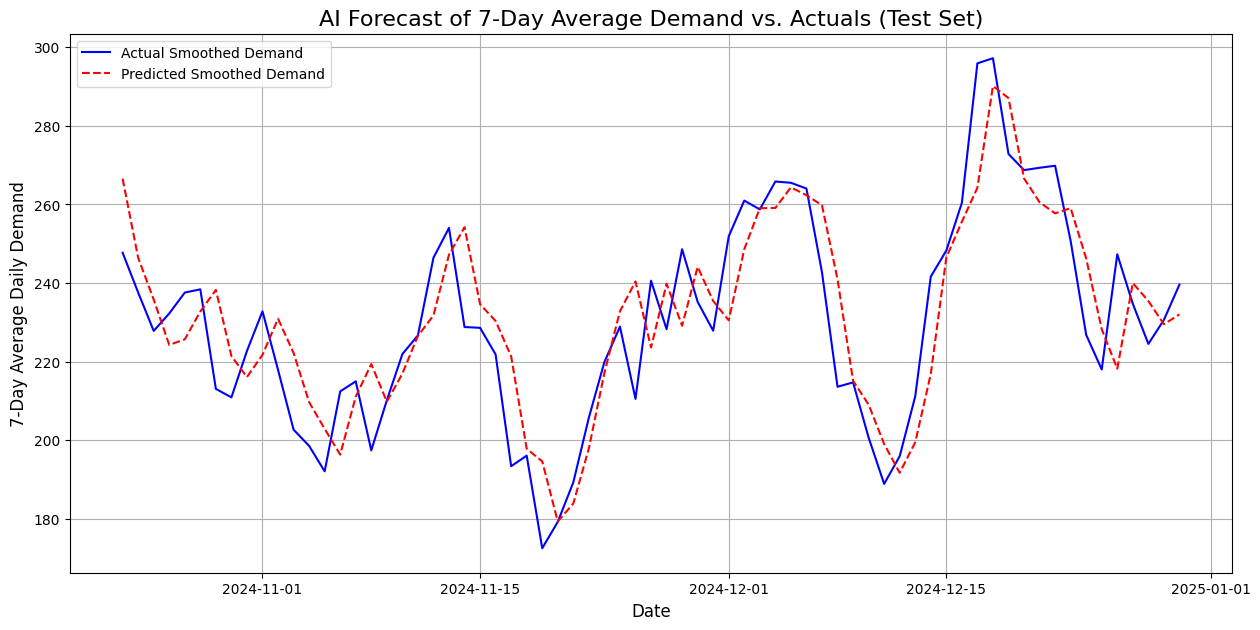

In [17]:
#Summing up all sales made within a one date
daily_demand_series = logistics_df.groupby('last_restock_date')['daily_demand'].sum()


daily_demand_series = daily_demand_series.asfreq('D', fill_value=0)

#calculates the average demand for a week
daily_demand_smoothed = daily_demand_series.rolling(window=7).mean().dropna()

#Places all numbers within the 0 and 1 range for computer to better understand
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(daily_demand_smoothed.values.reshape(-1, 1))

timesteps = 14
X, y = [], []
for i in range(len(scaled_data) - timesteps):
    X.append(scaled_data[i:(i + timesteps), 0])
    y.append(scaled_data[i + timesteps, 0])
X, y = np.array(X), np.array(y)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split the data.
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = Sequential([
    LSTM(units=150, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=150),
    Dropout(0.2),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=1)


predictions_scaled = model.predict(X_test)

predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"RMSE is: {rmse:.2f}")

# Plot the results
plt.figure(figsize=(15, 7))
plt.plot(daily_demand_smoothed.index[-len(y_test_actual):], y_test_actual, color='blue', label='Actual Smoothed Demand')
plt.plot(daily_demand_smoothed.index[-len(predictions):], predictions, color='red', linestyle='--', label='Predicted Smoothed Demand')
plt.title('AI Forecast of 7-Day Average Demand vs. Actuals (Test Set)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('7-Day Average Daily Demand', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()